<a href="https://colab.research.google.com/github/cristiangaymartin/tfm-estados-mercado/blob/main/notebooks/02_regimenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Detección de regímenes de mercado (HMM)

Detección no supervisada de estados de mercado sobre el S&P 500 mediante un
modelo oculto de Markov (HMM), usando rendimiento y volatilidad como variables.
Horizonte largo (histórico completo). Segunda etapa del análisis, tras `01_ingesta`.

In [2]:
%pip install hmmlearn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.5 MB/s eta 0:00:00


In [17]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

In [4]:
from google.colab import drive
drive.mount('/content/drive')

RUTA_DATOS = "/content/drive/MyDrive/TFM/data"

Mounted at /content/drive


In [5]:
# Leemos el CSV del S&P. index_col=0 y parse_dates para recuperar el índice de fechas.
sp = pd.read_csv(f"{RUTA_DATOS}/mercado_SP500.csv", index_col=0, parse_dates=True)

print("Forma:", sp.shape)
print("Rango:", sp.index.min().date(), "→", sp.index.max().date())
sp.head()

Forma: (9213, 3)
Rango: 1990-01-02 → 2026-08-03


,Close,ret_log,vol_21d
Date,,,
1990-01-02,359.690002,NaN,NaN
1990-01-03,358.760010,-0.002589,NaN
1990-01-04,355.670013,-0.008650,NaN
1990-01-05,352.200012,-0.009804,NaN
1990-01-08,353.790009,0.004504,NaN


In [7]:
# Nos quedamos con las dos features y eliminamos los NaN iniciales
datos_hmm = sp[["ret_log", "vol_21d"]].dropna()

print("Forma de los datos para el HMM:", datos_hmm.shape)
print("Rango:", datos_hmm.index.min().date(), "→", datos_hmm.index.max().date())
datos_hmm.head()

Forma de los datos para el HMM: (9192, 2)
Rango: 1990-01-31 → 2026-08-03


,ret_log,vol_21d
Date,,
1990-01-31,0.018710,0.010562
1990-02-01,-0.000882,0.010582
1990-02-02,0.006457,0.010773
1990-02-05,0.002806,0.010751
1990-02-06,-0.006621,0.010645


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(datos_hmm)

print("Media tras estandarizar (debe ser ~0):", X.mean(axis=0).round(3))
print("Desviación tras estandarizar (debe ser ~1):", X.std(axis=0).round(3))

Media tras estandarizar (debe ser ~0): [-0. -0.]
Desviación tras estandarizar (debe ser ~1): [1. 1.]


In [9]:
modelo_hmm = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

modelo_hmm.fit(X)

print("¿Convergió el modelo?", modelo_hmm.monitor_.converged)

estados = modelo_hmm.predict(X)
datos_hmm["estado"] = estados

print("\nDistribución de días por estado:")
print(datos_hmm["estado"].value_counts().sort_index())

¿Convergió el modelo? True

Distribución de días por estado:
estado
0    3486
1    4030
2    1676
Name: count, dtype: int64


In [10]:
# Media de rendimiento y volatilidad reales en cada estado, más el nº de días
perfil = datos_hmm.groupby("estado").agg(
    ret_medio=("ret_log", "mean"),
    vol_media=("vol_21d", "mean"),
    dias=("ret_log", "size")
)

# Añadimos el % de días que representa cada estado
perfil["pct_dias"] = (100 * perfil["dias"] / perfil["dias"].sum()).round(1)

perfil.round({"ret_medio": 5, "vol_media": 4})

,ret_medio,vol_media,dias,pct_dias
estado,,,,
0,0.00045,0.0099,3486,37.9
1,0.00052,0.0057,4030,43.8
2,-0.00030,0.0190,1676,18.2


In [11]:
# Mapeo de estado numérico a nombre económico, según sus características
nombres_estados = {
    1: "Calma alcista",      # vol baja, rendimiento positivo
    0: "Normal",             # vol media
    2: "Estrés bajista",     # vol alta, rendimiento negativo
}

datos_hmm["regimen"] = datos_hmm["estado"].map(nombres_estados)

# Comprobamos el reparto con nombres
print(datos_hmm["regimen"].value_counts())

regimen
Calma alcista     4030
Normal            3486
Estrés bajista    1676
Name: count, dtype: int64


In [12]:
# Traemos el precio de cierre junto a los regímenes (alineados por fecha)
plot_df = datos_hmm.join(sp["Close"])

# Colores para cada régimen
colores = {
    "Calma alcista":  "#2ca02c",   # verde
    "Normal":         "#ff7f0e",   # naranja
    "Estrés bajista": "#d62728",   # rojo
}

print(plot_df[["Close", "regimen"]].head())

                 Close regimen
Date                          
1990-01-31  329.079987  Normal
1990-02-01  328.790009  Normal
1990-02-02  330.920013  Normal
1990-02-05  331.850006  Normal
1990-02-06  329.660004  Normal


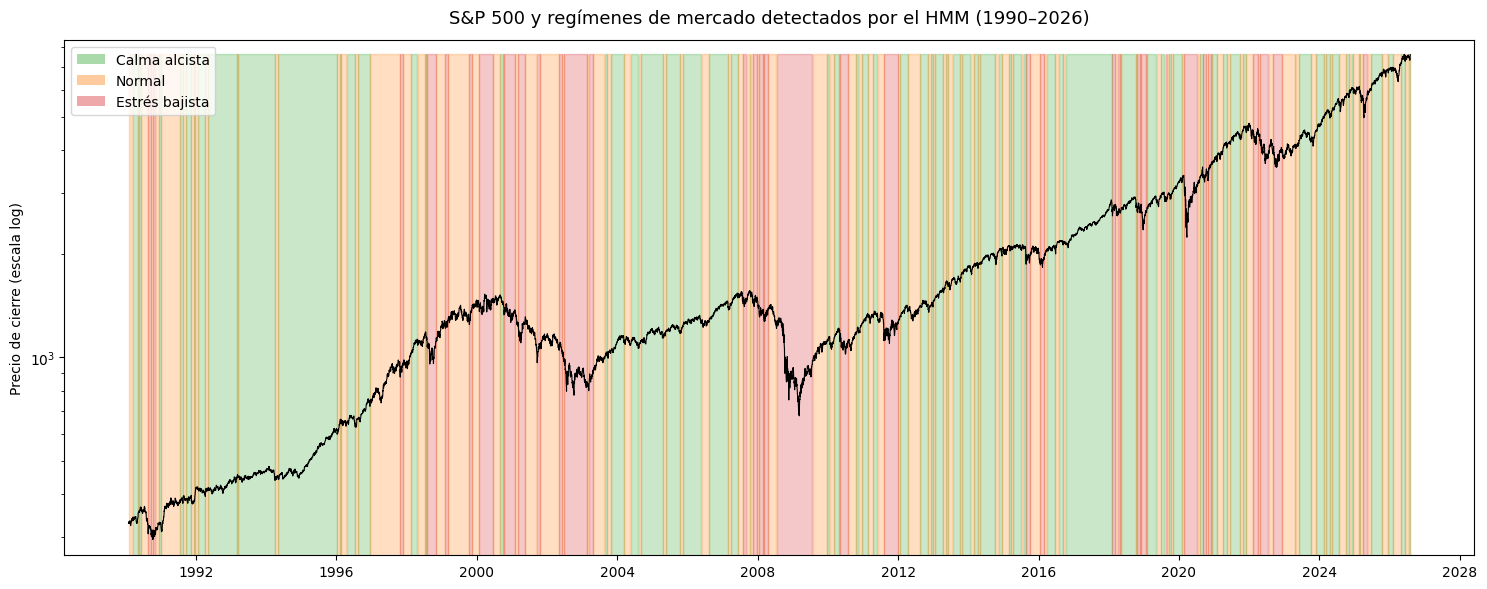

In [18]:
fig, ax = plt.subplots(figsize=(15, 6))

# Línea del precio (en gris, para que resalten los colores de fondo)
ax.plot(plot_df.index, plot_df["Close"], color="black", linewidth=0.8, zorder=3)

# Coloreamos el fondo según el régimen de cada día
for regimen, color in colores.items():
    mask = plot_df["regimen"] == regimen
    ax.fill_between(plot_df.index, 0, plot_df["Close"].max(),
                    where=mask, color=color, alpha=0.25, zorder=1)

ax.set_title("S&P 500 y regímenes de mercado detectados por el HMM (1990–2026)", fontsize=13, pad=12)
ax.set_ylabel("Precio de cierre (escala log)")
ax.set_yscale("log")   # escala logarítmica: los cambios % se ven proporcionales
ax.set_ylim(plot_df["Close"].min()*0.9, plot_df["Close"].max()*1.1)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=c, alpha=0.4, label=r) for r, c in colores.items()]
ax.legend(handles=leyenda, loc="upper left")

plt.tight_layout()
RUTA_DOCS = "/content/drive/MyDrive/TFM/docs"
os.makedirs(RUTA_DOCS, exist_ok=True)

plt.savefig(f"{RUTA_DOCS}/regimenes_sp500.png", dpi=150, bbox_inches="tight")
plt.show()